# GAT — Graph Attention Network for MEG Classification

Personal experiment — separate from the group submission.

**Architecture:**
1. Temporal feature extraction per sensor (1D Conv)
2. Spectral band power features (delta, theta, alpha, beta, gamma)
3. GAT layers — learns spatial relations between 248 sensors
4. Global mean pooling over nodes
5. Dense(4) classification

## 1. Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt

CLASSES = ["rest", "motor", "math", "memory"]

def load_dataset(name):
    return np.load(f"Preprocessed data/{name}.npy")

# Windowed data — 512 train windows, 64 test windows
X_train = load_dataset("X_intra_train_w")
X_test  = load_dataset("X_intra_test_w")
y_train = load_dataset("y_intra_train_w")
y_test  = load_dataset("y_intra_test_w")

print("X_train:", X_train.shape)  # (512, 248, 500)
print("X_test: ", X_test.shape)   # (64, 248, 500)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (512, 248, 500)
X_test:  (64, 248, 500)
y_train: (512,)
y_test:  (64,)


## 2. Data Exploration

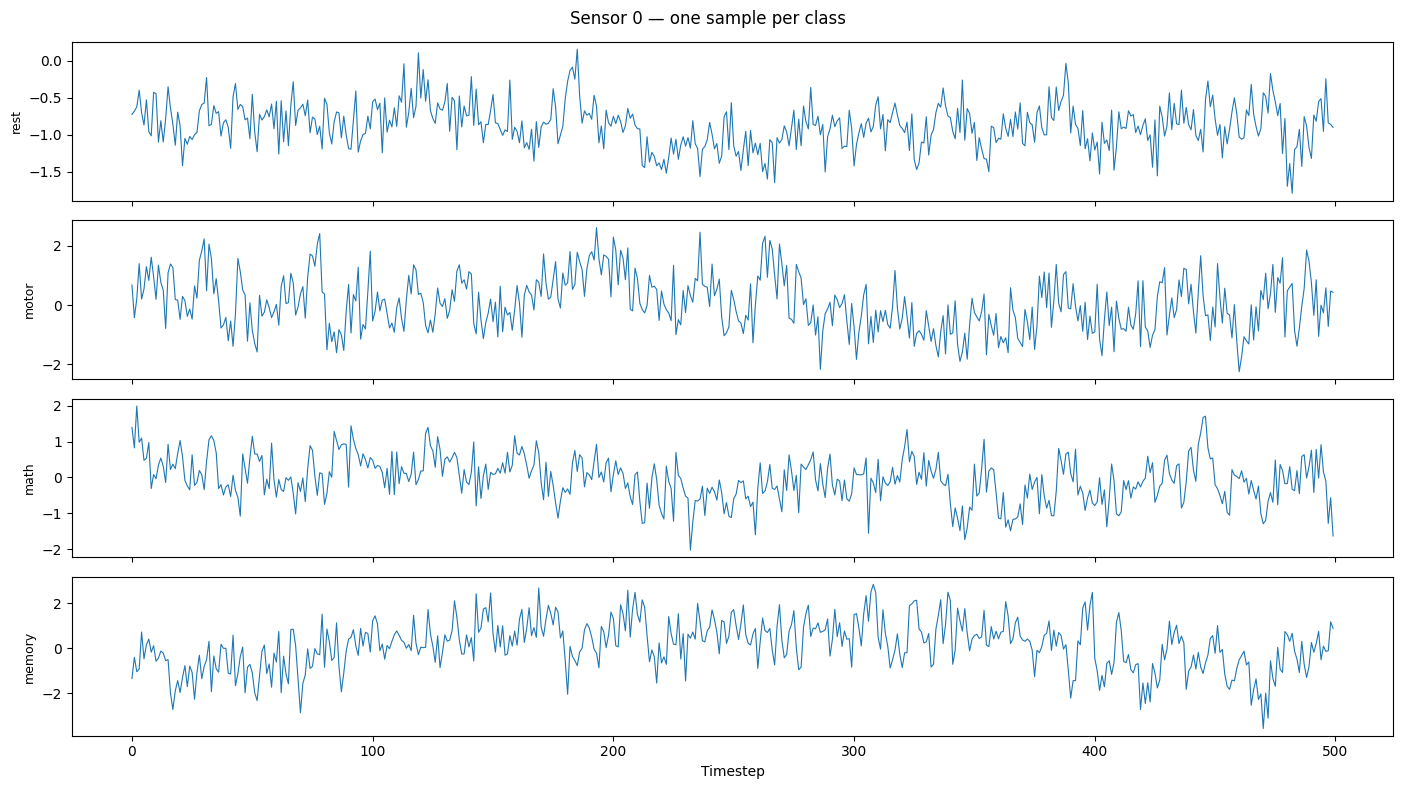

In [2]:
# One sample per class — sensor 0
SENSOR = 0

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for i, (ax, label) in enumerate(zip(axes, CLASSES)):
    idx = np.where(y_train == i)[0][0]
    ax.plot(X_train[idx, SENSOR, :], linewidth=0.8)
    ax.set_ylabel(label, fontsize=9)
axes[-1].set_xlabel("Timestep")
plt.suptitle(f"Sensor {SENSOR} — one sample per class")
plt.tight_layout()
plt.show()

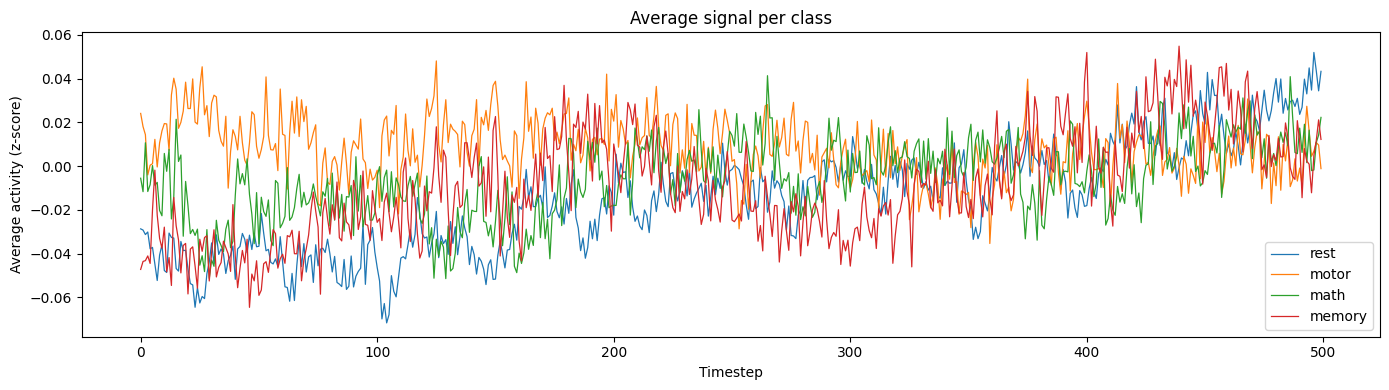

In [3]:
# Average signal per class (mean over all sensors and samples)
fig, ax = plt.subplots(figsize=(14, 4))
for i, label in enumerate(CLASSES):
    idx = np.where(y_train == i)[0]
    mean_signal = X_train[idx].mean(axis=(0, 1))
    ax.plot(mean_signal, label=label, linewidth=0.9)
ax.set_xlabel("Timestep")
ax.set_ylabel("Average activity (z-score)")
ax.legend()
ax.set_title("Average signal per class")
plt.tight_layout()
plt.show()

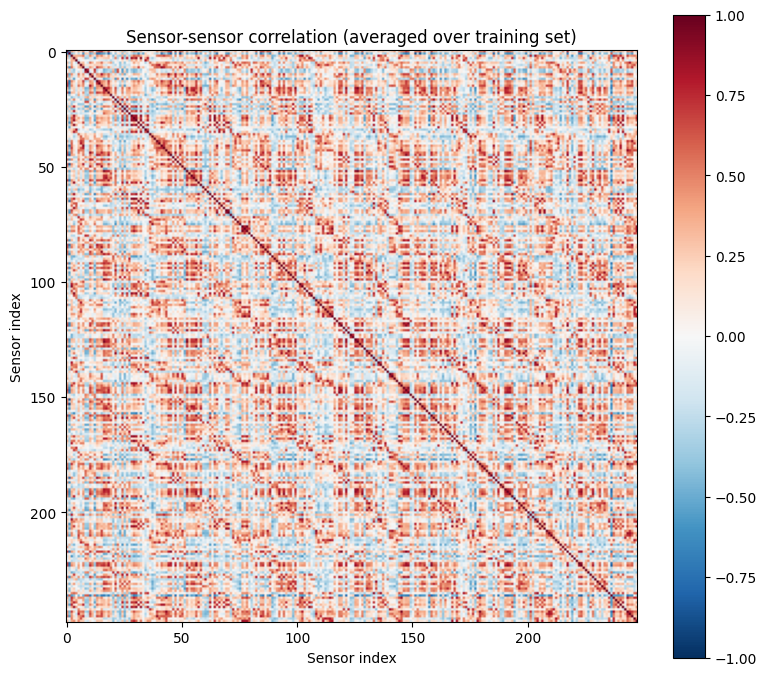

In [4]:
# Sensor-sensor correlation matrix
X_mean = X_train.mean(axis=0)
corr_matrix = np.corrcoef(X_mean)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_title("Sensor-sensor correlation (averaged over training set)")
ax.set_xlabel("Sensor index")
ax.set_ylabel("Sensor index")
plt.tight_layout()
plt.show()

## 3. Adjacency Matrix (A1 — Distance-based)

Sensors are nodes in a graph. Edge weights are defined by physical distance on the MEG helmet using a Gaussian kernel:

$$A_{ij} = \exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right)$$

In [5]:
import mne
from scipy.spatial.distance import cdist

# Load BTi248 sensor layout (2D projected positions on the helmet)
layout = mne.channels.read_layout('magnesWH3600')
pos = layout.pos[:, :2]  # (248, 2)

# Pairwise Euclidean distances
dist_matrix = cdist(pos, pos, metric='euclidean')

# Gaussian kernel
sigma = dist_matrix.std()
A_distance = np.exp(-dist_matrix**2 / (2 * sigma**2))
np.fill_diagonal(A_distance, 0)

print("Shape:", A_distance.shape)
print("Min:", A_distance.min().round(4), "Max:", A_distance.max().round(4))

Shape: (248, 248)
Min: 0.0 Max: 0.982


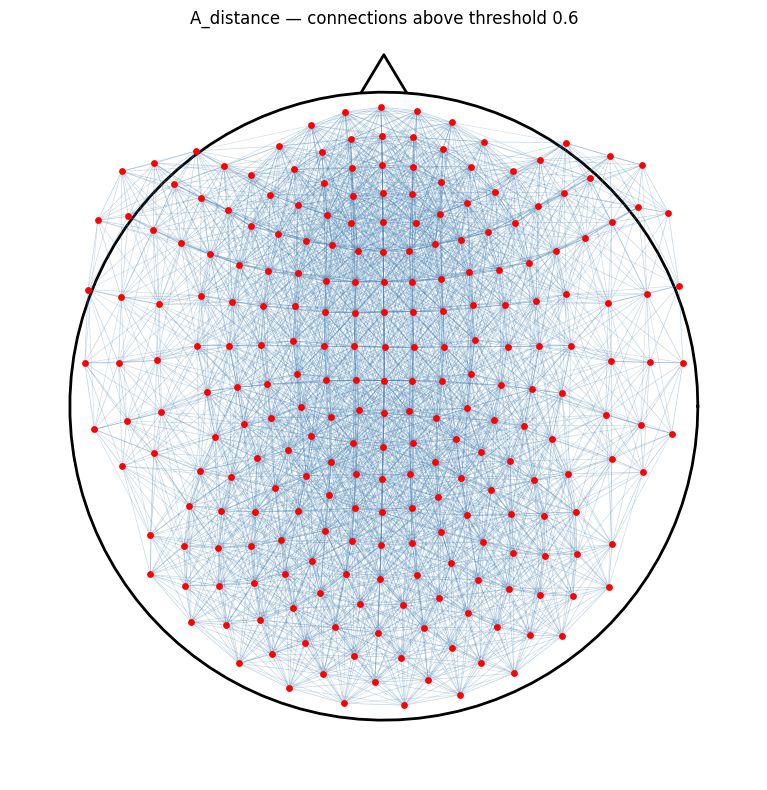

In [6]:
# Visualize sensor connections on head
pos_norm = (pos - pos.min(axis=0)) / (pos.max(axis=0) - pos.min(axis=0))
pos_norm = pos_norm * 0.8 + 0.1

fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(0.5 + 0.42 * np.cos(theta), 0.5 + 0.42 * np.sin(theta), 'k-', linewidth=2)
ax.plot([0.47, 0.5, 0.53], [0.92, 0.97, 0.92], 'k-', linewidth=2)

threshold = 0.6
for i in range(248):
    for j in range(i + 1, 248):
        if A_distance[i, j] > threshold:
            ax.plot([pos_norm[i, 0], pos_norm[j, 0]],
                    [pos_norm[i, 1], pos_norm[j, 1]],
                    color='steelblue', alpha=A_distance[i, j] * 0.4, linewidth=0.5)

ax.scatter(pos_norm[:, 0], pos_norm[:, 1], c='red', s=15, zorder=5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'A_distance — connections above threshold {threshold}')
plt.tight_layout()
plt.show()

Optimal k: 4


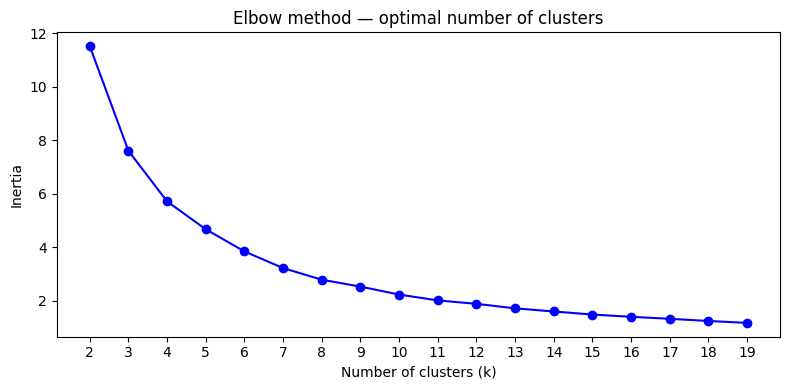

In [7]:
# Elbow method — find optimal number of sensor clusters
from sklearn.cluster import KMeans

inertias = []
k_range  = range(2, 20)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pos_norm)
    inertias.append(km.inertia_)

optimal_k = k_range[np.argmax(np.diff(inertias, 2)) + 2]
print(f"Optimal k: {optimal_k}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method — optimal number of clusters')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

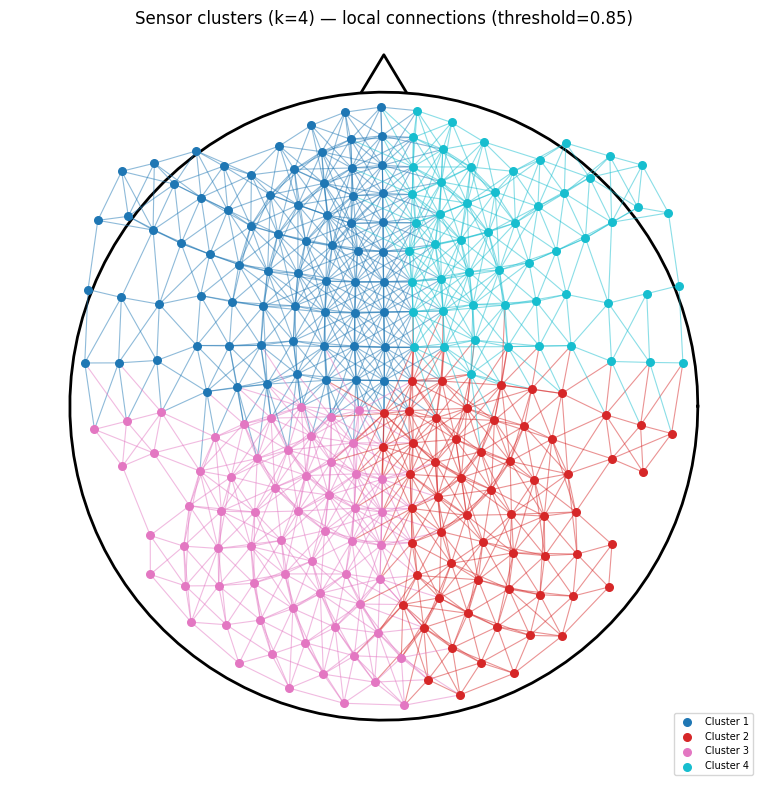

In [8]:
# Visualize sensor clusters on head
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pos_norm)
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(0.5 + 0.42 * np.cos(theta), 0.5 + 0.42 * np.sin(theta), 'k-', linewidth=2)
ax.plot([0.47, 0.5, 0.53], [0.92, 0.97, 0.92], 'k-', linewidth=2)

threshold = 0.85
for i in range(248):
    for j in range(i + 1, 248):
        if A_distance[i, j] > threshold:
            c = colors[cluster_labels[i]]
            ax.plot([pos_norm[i, 0], pos_norm[j, 0]],
                    [pos_norm[i, 1], pos_norm[j, 1]],
                    color=c[:3], alpha=0.5, linewidth=0.8)

for k in range(optimal_k):
    mask = cluster_labels == k
    ax.scatter(pos_norm[mask, 0], pos_norm[mask, 1],
               c=[colors[k]], s=30, zorder=5, label=f'Cluster {k+1}')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Sensor clusters (k={optimal_k}) — local connections (threshold={threshold})')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.show()

## 4. A Matrix Normalization

Following Kipf & Welling (2017), lecture slides 417-418:
1. Add self-loops: $\hat{A} = A + I$
2. Symmetric normalization: $\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}$

In [9]:
# Step 1: Add self-loops
A_hat = A_distance + np.eye(248)

# Step 2: Degree matrix
degree     = A_hat.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))

# Step 3: Normalize
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

print("A_norm shape:", A_norm.shape)
print("Row sum min:", A_norm.sum(axis=1).min().round(4))
print("Row sum max:", A_norm.sum(axis=1).max().round(4))

A_norm shape: (248, 248)
Row sum min: 0.743
Row sum max: 1.1242


## 5. Spectral Band Power Features

Extract band power per sensor for 5 frequency bands: delta, theta, alpha, beta, gamma.
These are concatenated to the temporal features before the GAT layers.

In [10]:
from scipy.signal import butter, sosfiltfilt

bands = {'delta': (1,4), 'theta': (4,8), 'alpha': (8,13), 'beta': (13,30), 'gamma': (30,50)}
fs = 254.0

def extract_band_power(X, fs, bands):
    n_samples, n_sensors, n_times = X.shape
    n_bands = len(bands)
    bp = np.zeros((n_samples, n_sensors, n_bands), dtype='float32')
    for b_idx, (_, (f_low, f_high)) in enumerate(bands.items()):
        sos = butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
        for s in range(n_samples):
            for ch in range(n_sensors):
                filtered = sosfiltfilt(sos, X[s, ch])
                bp[s, ch, b_idx] = np.var(filtered)
    return bp

print("Extracting band power features (this takes a few minutes)...")
bp_train = extract_band_power(X_train, fs, bands)
bp_test  = extract_band_power(X_test,  fs, bands)
print("Train band power:", bp_train.shape)  # (512, 248, 5)
print("Test band power: ", bp_test.shape)   # (64, 248, 5)

Extracting band power features (this takes a few minutes)...
Train band power: (512, 248, 5)
Test band power:  (64, 248, 5)


## 6. Model Architecture

**GATLayer** — single GAT layer (Veličković et al. 2018, Lecture 8 slides 423-425)

**MEG_GAT** — full model:
- Temporal Conv1D per sensor → compress 500 timesteps to 32 features
- Concatenate band power features (5 bands)
- 2× GAT layers with BatchNorm
- Global mean pooling → Dense(4)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GATLayer(nn.Module):
    """
    GAT layer — Veličković et al. 2018 (Lecture 8, slides 423-425)
    α_ij = softmax( LeakyReLU( a^T [Wh_i || Wh_j] ) )
    h'_i  = σ( Σ_j α_ij W h_j )
    """
    def __init__(self, in_features, out_features, dropout=0.3):
        super().__init__()
        self.W          = nn.Linear(in_features, out_features, bias=False)
        self.a_src      = nn.Linear(out_features, 1, bias=False)
        self.a_dst      = nn.Linear(out_features, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, H, A):
        B, N, _ = H.shape
        Wh    = self.W(H)
        e_src = self.a_src(Wh)
        e_dst = self.a_dst(Wh)
        e     = self.leaky_relu(e_src + e_dst.transpose(1, 2))
        mask  = (A == 0).unsqueeze(0).expand(B, -1, -1)
        e     = e.masked_fill(mask, float('-inf'))
        alpha = self.dropout(F.softmax(e, dim=-1))
        return F.elu(torch.bmm(alpha, Wh))


class MEG_GAT(nn.Module):
    def __init__(self, n_sensors=248, n_timesteps=500,
                 temporal_features=32, n_bands=5, gat_hidden=16, n_classes=4):
        super().__init__()

        self.temporal_conv = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=25, stride=5),
            nn.ReLU(),
            nn.Conv1d(8, temporal_features, kernel_size=10, stride=5),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.bn_temporal = nn.BatchNorm1d(temporal_features)

        self.gat1 = GATLayer(temporal_features + n_bands, gat_hidden)
        self.bn1  = nn.BatchNorm1d(gat_hidden)

        self.gat2 = GATLayer(gat_hidden, gat_hidden)
        self.bn2  = nn.BatchNorm1d(gat_hidden)

        self.classifier = nn.Linear(gat_hidden, n_classes)

    def forward(self, X, A, BP):
        B, N, T = X.shape

        # Temporal conv + BN
        X = X.reshape(B * N, 1, T)
        X = self.temporal_conv(X).squeeze(-1)          # (B*N, temporal_features)
        X = self.bn_temporal(X)
        X = X.reshape(B, N, -1)                        # (B, N, temporal_features)

        # Concatenate band power features
        X = torch.cat([X, BP], dim=-1)                 # (B, N, temporal_features + n_bands)

        # GAT layers
        X = self.gat1(X, A)
        X = self.bn1(X.reshape(B * N, -1)).reshape(B, N, -1)

        X = self.gat2(X, A)
        X = self.bn2(X.reshape(B * N, -1)).reshape(B, N, -1)

        X = X.mean(dim=1)
        return self.classifier(X)


## 7. Training

- Mini-batch training (batch_size=32) with shuffling
- Early stopping on test loss (patience=20)
- Majority vote evaluation at recording level (8 recordings, 8 windows each)

In [12]:
import torch
import torch.optim as optim

X_train_t  = torch.tensor(X_train,  dtype=torch.float32)
X_test_t   = torch.tensor(X_test,   dtype=torch.float32)
y_train_t  = torch.tensor(y_train,  dtype=torch.long)
y_test_t   = torch.tensor(y_test,   dtype=torch.long)
BP_train_t = torch.tensor(bp_train, dtype=torch.float32)
BP_test_t  = torch.tensor(bp_test,  dtype=torch.float32)

A_t = torch.tensor((A_norm > 0.01).astype(float) * A_norm, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train_t, BP_train_t, y_train_t)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

model     = MEG_GAT()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_test_loss    = float('inf')
best_epoch        = 0
best_model_state  = None
patience          = 20
epochs_no_improve = 0

n_epochs = 150
for epoch in range(n_epochs):
    model.train()
    for X_batch, BP_batch, y_batch in loader:
        optimizer.zero_grad()
        out  = model(X_batch, A_t, BP_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out_train  = model(X_train_t, A_t, BP_train_t)
        loss_train = criterion(out_train, y_train_t).item()
        acc_train  = (out_train.argmax(dim=1) == y_train_t).float().mean().item()

        out_test   = model(X_test_t, A_t, BP_test_t)
        loss_test  = criterion(out_test, y_test_t).item()
        acc_test   = (out_test.argmax(dim=1) == y_test_t).float().mean().item()

    if loss_test < best_test_loss:
        best_test_loss    = loss_test
        best_epoch        = epoch + 1
        best_model_state  = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train loss: {loss_train:.4f}  acc: {acc_train:.2%} | Test loss: {loss_test:.4f}  acc: {acc_test:.2%}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (best epoch: {best_epoch})")
        break

model.load_state_dict(best_model_state)
print(f"\nBest model restored from epoch {best_epoch} (test loss: {best_test_loss:.4f})")

# --- Majority vote evaluation ---
n_recordings    = 8
windows_per_rec = len(X_test) // n_recordings
y_test_orig     = np.load("Preprocessed data/y_intra_test.npy")

model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_test_t, A_t, BP_test_t), dim=1).numpy()

mv_preds = []
for i in range(n_recordings):
    avg_prob = probs[i * windows_per_rec:(i + 1) * windows_per_rec].mean(axis=0)
    mv_preds.append(np.argmax(avg_prob))

mv_acc = np.mean(np.array(mv_preds) == y_test_orig)
print(f"Majority vote accuracy (recording-level, {n_recordings} recordings): {mv_acc:.2%}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test_orig, mv_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — majority vote ({mv_acc:.0%} accuracy)')
plt.tight_layout()
plt.show()

print(classification_report(y_test_orig, mv_preds, target_names=CLASSES))